In [2]:
import pandas as pd
from pathlib import Path
from typing import List, Tuple

# -------- user paths / tickers (edit if needed) --------
TICKERS: List[str] = ["AAPL", "MSFT", "GOOG"]
DATA_DIR = Path(".")
FILE_TMPL = "{tkr}_2005_2021_clean.csv"

# -------- helpers (fixed _clean_index) -----------------
def _clean_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    df = df[~df.index.isna()]               # drop NaT rows
    return df.sort_index()                  # ensure monotonic

def _split_col(df: pd.DataFrame, field: str) -> pd.Series:
    if field in df.columns:
        return df[field]
    if df.columns.nlevels == 2:
        return df.xs(field, level=0, axis=1).squeeze()
    if df.columns.nlevels == 3:
        return df.xs(("Price", field), axis=1).squeeze()
    raise KeyError(field)

def load_panels(
    tickers: List[str], data_dir: Path, tmpl: str
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    price, volume, hi, lo = {}, {}, {}, {}
    for tkr in tickers:
        fp = data_dir / tmpl.format(tkr=tkr)
        raw = pd.read_csv(fp, index_col=0).pipe(_clean_index)
        price[tkr]  = _split_col(raw, "Adj Close")
        volume[tkr] = _split_col(raw, "Volume")
        hi[tkr]     = _split_col(raw, "High")
        lo[tkr]     = _split_col(raw, "Low")
    return (
        pd.concat(price,  axis=1).sort_index(),
        pd.concat(volume, axis=1).sort_index(),
        pd.concat(hi,     axis=1).sort_index(),
        pd.concat(lo,     axis=1).sort_index(),
    )

# -------- run the slice test ---------------------------
price, *_ = load_panels(TICKERS, DATA_DIR, FILE_TMPL)

assert price.index.is_monotonic_increasing, "Index still not sorted!"
assert pd.Timestamp("2018-01-02") in price.index
assert pd.Timestamp("2021-12-31") in price.index

try:
    _ = price.loc["2018-01-02":"2021-12-31"]
    print("✅ Slice works — index clean & monotonic. Ready to run back-test.")
except KeyError as err:
    print("❌ Still failing:", err)

✅ Slice works — index clean & monotonic. Ready to run back-test.


/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2639/3543891003.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2639/3543891003.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2639/3543891003.py:13: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")


/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2844/4177001267.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2844/4177001267.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2844/4177001267.py:39: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz


Final cumulative return : 299.16%

Portfolio
Total :   3.99× (+299.2%)
AnnRet: 41.40%
AnnVol: 28.34%
Sharpe:   1.46

Benchmark
Total :   1.76× (+75.7%)
AnnRet: 15.14%
AnnVol: 21.24%
Sharpe:   0.71


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 4017 times so far.

  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 4018 times so far.

  warnings.warn(msg, UserWarning)
/opt/anacond

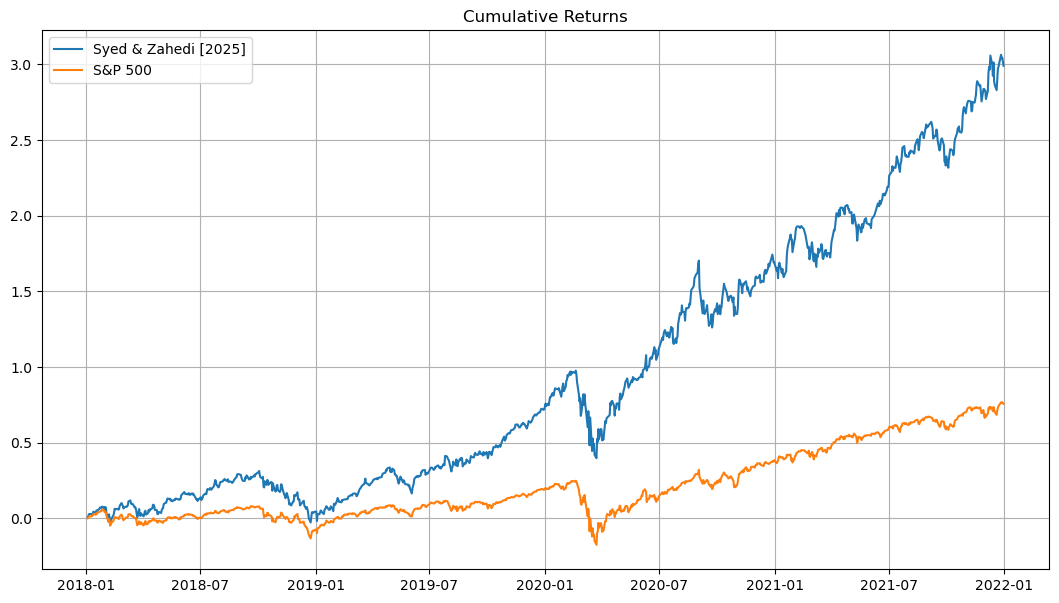

In [4]:
# -*- coding: utf-8 -*-
"""
SCNN-driven mean–variance back-test (final robust version)
"""
from __future__ import annotations
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message=r"This use of `\*`.*matrix")

# ───────────── user settings ─────────────
TICKERS = ["AAPL", "MSFT", "GOOG"]
DATA_DIR = Path(".")
FILE_TMPL = "{tkr}_2005_2021_clean.csv"
PRED_CSV  = Path("oos_predictions_2018on.csv")
SPX_CSV   = Path("sp500_2005_2021_clean.csv")

ROLL_WIN = 30
W_MAX    = 0.40

@dataclass
class Parameters:
    gamma_trade: float = 0.10
    gamma_risk : float = 0.50
    a_lin: float = 1e-3
    b_nl : float = 5e-4


# ═══ helpers: realised data ═══════════════════════════════════════
def _clean_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    return df.loc[~df.index.isna()].sort_index()

def _split_num(df: pd.DataFrame, field: str) -> pd.Series:
    if field in df.columns:
        col = df[field]
    elif df.columns.nlevels == 2:
        col = df.xs(field, level=0, axis=1).squeeze()
    else:
        col = df.xs(("Price", field), axis=1).squeeze()
    return pd.to_numeric(col, errors="coerce")

def load_panels(tickers: List[str]) -> Tuple[pd.DataFrame, ...]:
    price, vol, hi, lo = {}, {}, {}, {}
    for t in tickers:
        raw = pd.read_csv(DATA_DIR / FILE_TMPL.format(tkr=t), index_col=0)\
                 .pipe(_clean_index)
        price[t] = _split_num(raw, "Adj Close")
        vol[t]   = _split_num(raw, "Volume")
        hi[t]    = _split_num(raw, "High")
        lo[t]    = _split_num(raw, "Low")
    return (pd.concat(d, axis=1).sort_index() for d in (price, vol, hi, lo))

# ═══ helpers: forecasts ═══════════════════════════════════════════
def load_predictions() -> pd.DataFrame:
    df = pd.read_csv(PRED_CSV, index_col=0, parse_dates=True)
    if df.columns.nlevels == 2 and df.columns.get_level_values(0)[0] == "Price":
        df.columns = df.columns.get_level_values(1)
    if "Price" in df.columns:
        df = df.drop(columns="Price")
    return df.sort_index()

def split_predictions(pred: pd.DataFrame) -> Tuple[pd.DataFrame, ...]:
    mu  = np.exp(pred[[f"{t}_log_ret"  for t in TICKERS]].apply(pd.to_numeric, errors="coerce")) - 1
    sig =        pred[[f"{t}_sigma20" for t in TICKERS]].apply(pd.to_numeric, errors="coerce")
    trn =        pred[[f"{t}_TurnUSD" for t in TICKERS]].apply(pd.to_numeric, errors="coerce")
    mu.columns = sig.columns = trn.columns = TICKERS
    return mu, sig, trn

# ═══ benchmark ════════════════════════════════════════════════════
def load_benchmark(start: str, end: str) -> pd.Series:
    df = pd.read_csv(SPX_CSV, index_col=0, parse_dates=True, header=[0,1])
    if df.columns.nlevels == 1:
        px = df["Adj Close"]
    elif df.columns.nlevels == 2:
        px = df.xs("Adj Close", level=1 if df.columns.levels[0][0]=="Price" else 0, axis=1)
    else:
        px = df.xs(("Price","Adj Close"), axis=1).squeeze()
    px = px.sort_index().loc[start:end].ffill()
    return (1 + px.pct_change().fillna(0)).cumprod() - 1

# ═══ optimiser ════════════════════════════════════════════════════
def optimise(mu, sig, trn, w_prev, aum, p):
    V_w = trn.values / aum
    z   = cp.Variable(len(mu))
    phi = cp.sum(p.a_lin*cp.abs(z) + p.b_nl*sig.values*cp.power(cp.abs(z),1.5)/cp.sqrt(V_w))
    risk= cp.quad_form(w_prev+z, np.diag(sig.values**2))
    cp.Problem(cp.Maximize(mu.values@z - p.gamma_trade*phi - p.gamma_risk*risk),
               [cp.sum(z)==0, w_prev+z>=0, w_prev+z<=W_MAX]).solve(solver="SCS")
    z_val = z.value
    return np.zeros(len(mu)) if z_val is None or np.isnan(z_val).any() else z_val

# ═══ back-test loop ═══════════════════════════════════════════════
def backtest(start: str, end: str, initial_capital=1e6):
    price, vol_s, hi, lo = load_panels(TICKERS)
    price, vol_s, hi, lo = (df.loc[start:end] for df in (price, vol_s, hi, lo))
    mu_hat, sig_hat, trn_hat = split_predictions(load_predictions().loc[start:end])

    # remove any row with NaNs in *any* panel
    good = ~(price.isna().any(axis=1) | mu_hat.isna().any(axis=1) |
             sig_hat.isna().any(axis=1) | trn_hat.isna().any(axis=1))
    price, mu_hat, sig_hat, trn_hat = (df[good] for df in (price, mu_hat, sig_hat, trn_hat))
    if price.empty: raise ValueError("No valid rows after NaN filtering.")

    dates = price.index
    turn_med = ((hi + lo)/2 * vol_s).rolling(ROLL_WIN).median().reindex(dates)\
                 .fillna(method="ffill").fillna(method="bfill")

    wealth = np.full(len(dates), initial_capital, float)
    W = np.zeros((len(dates), len(TICKERS))); W[0] = 1/len(TICKERS)
    prm = Parameters()

    for t in range(len(dates)-1):
        z = optimise(mu_hat.iloc[t+1], sig_hat.iloc[t+1], trn_hat.iloc[t+1],
                     W[t], wealth[t], prm)
        W[t+1] = W[t] + z
        gross = W[t+1] @ (price.iloc[t+1].values / price.iloc[t].values - 1)
        tm = turn_med.iloc[t+1].values
        tm = np.where(tm<=0, 1e-8, tm)
        impact = np.sum(5e-4 * sig_hat.iloc[t+1].values * np.power(np.abs(z),1.5) /
                        np.sqrt(tm / wealth[t]))
        wealth[t+1] = wealth[t] * (1 + gross - impact)

    return pd.Series(wealth[1:]/initial_capital - 1, index=dates[1:])

# ═══ metrics / pretty print ═══════════════════════════════════════
def metrics(c: pd.Series) -> Dict[str, float]:
    if c.empty:
        return dict.fromkeys(["Total","AnnRet","AnnVol","Sharpe"], np.nan)
    total = float(c.iloc[-1])
    daily = c.diff().fillna(0) / (1 + c.shift())
    ann_r = float((1+total)**(252/len(c)) - 1)
    ann_v = float(daily.std(ddof=0)*np.sqrt(252))
    sharpe= ann_r/ann_v if ann_v>0 else np.nan
    return {"Total":total,"AnnRet":ann_r,"AnnVol":ann_v,"Sharpe":sharpe}

def pp(lbl,d):
    print(f"\n{lbl}")
    print(f"Total : {1+d['Total']:6.2f}× ({d['Total']:+6.1%})")
    print(f"AnnRet: {d['AnnRet']:6.2%}")
    print(f"AnnVol: {d['AnnVol']:6.2%}")
    print(f"Sharpe: {d['Sharpe']:6.2f}")

# ═══ run ═══════════════════════════════════════════════════════════
cum = backtest("2018-01-02","2021-12-31")
print(f"\nFinal cumulative return : {cum.iloc[-1]:.2%}")
pp("Portfolio", metrics(cum))

bench = load_benchmark(cum.index[0].strftime("%Y-%m-%d"),
                       cum.index[-1].strftime("%Y-%m-%d"))
pp("Benchmark", metrics(bench.reindex(cum.index)))

plt.figure(figsize=(13,7))
plt.plot(cum, label="Syed & Zahedi [2025]")
plt.plot(bench, label="S&P 500")
plt.title("Cumulative Returns"); plt.legend(); plt.grid(True); plt.show()


## works but no weights output!

/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2899/3315516990.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2899/3315516990.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2899/3315516990.py:57: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz


Final cumulative return : 299.16%

Portfolio
Total :   3.99× (+299.2%)
AnnRet: 41.40%
AnnVol: 28.34%
Sharpe:   1.46

Benchmark
Total :   1.76× (+75.7%)
AnnRet: 15.14%
AnnVol: 21.24%
Sharpe:   0.71


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 985 times so far.

  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 986 times so far.

  warnings.warn(msg, UserWarning)
/opt/anaconda3

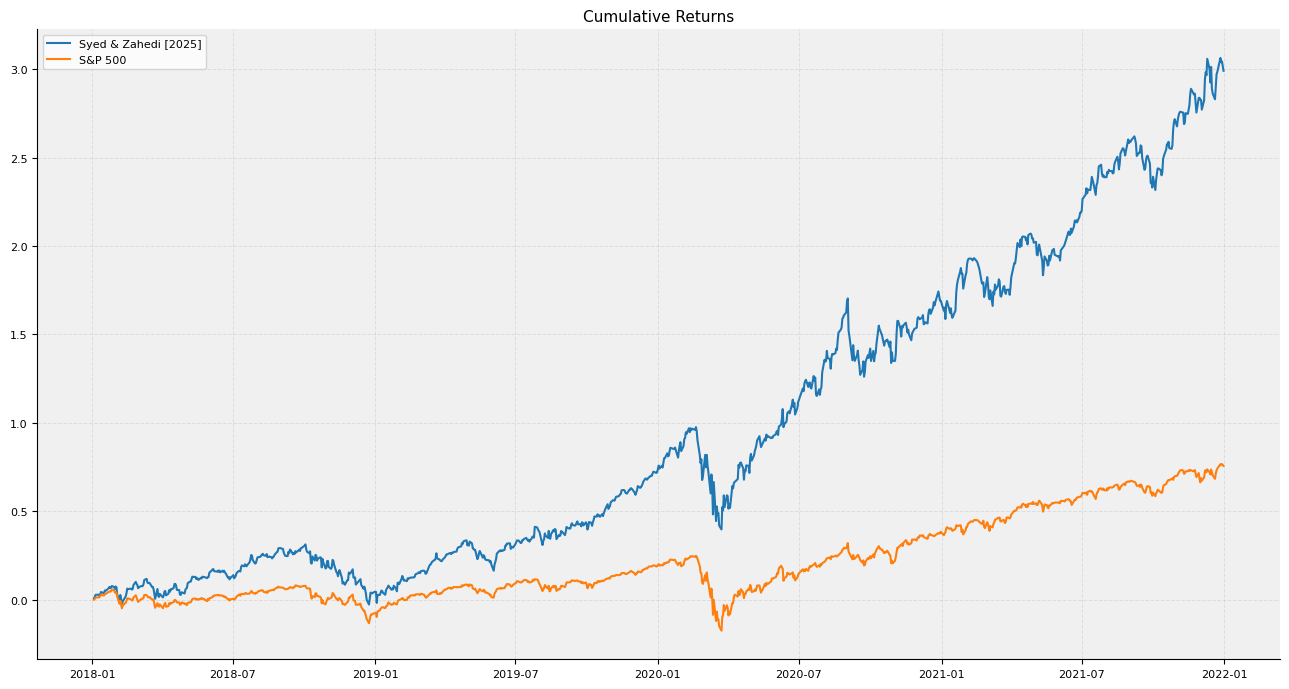

In [1]:
# -*- coding: utf-8 -*-
"""
SCNN-driven mean–variance back-test  (robust + styled plot)
-----------------------------------------------------------
Requires in the working directory:
  • <TICKER>_2005_2021_clean.csv   (AAPL, MSFT, GOOG)
  • oos_predictions_2018on.csv
  • sp500_2005_2021_clean.csv
"""
from __future__ import annotations
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message=r"This use of `\*`.*matrix")

# ───────────── user settings ─────────────
TICKERS = ["AAPL", "MSFT", "GOOG"]
DATA_DIR = Path(".")
FILE_TMPL = "{tkr}_2005_2021_clean.csv"
PRED_CSV  = Path("oos_predictions_2018on.csv")
SPX_CSV   = Path("sp500_2005_2021_clean.csv")

ROLL_WIN = 30
W_MAX    = 0.40

@dataclass
class Parameters:
    gamma_trade: float = 0.10
    gamma_risk : float = 0.50
    a_lin: float = 1e-3
    b_nl : float = 5e-4


# ═══ helper: axis styling ════════════════════════════════════════════
def style_axes(ax, *, is_bottom: bool = True) -> None:
    """Light grey background, dashed grid, clean spines."""
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, which="major", axis="both",
            linestyle="--", linewidth=0.7, alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if not is_bottom:
        ax.tick_params(labelbottom=False)


# ═══ realised-data helpers ═══════════════════════════════════════════
def _clean_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    return df.loc[~df.index.isna()].sort_index()

def _split_num(df: pd.DataFrame, field: str) -> pd.Series:
    if field in df.columns:
        col = df[field]
    elif df.columns.nlevels == 2:
        col = df.xs(field, level=0, axis=1).squeeze()
    else:
        col = df.xs(("Price", field), axis=1).squeeze()
    return pd.to_numeric(col, errors="coerce")

def load_panels(tickers: List[str]) -> Tuple[pd.DataFrame, ...]:
    price, vol, hi, lo = {}, {}, {}, {}
    for t in tickers:
        raw = pd.read_csv(DATA_DIR / FILE_TMPL.format(tkr=t), index_col=0)\
                 .pipe(_clean_index)
        price[t] = _split_num(raw, "Adj Close")
        vol[t]   = _split_num(raw, "Volume")
        hi[t]    = _split_num(raw, "High")
        lo[t]    = _split_num(raw, "Low")
    return (pd.concat(d, axis=1).sort_index() for d in (price, vol, hi, lo))


# ═══ forecast helpers ════════════════════════════════════════════════
def load_predictions() -> pd.DataFrame:
    df = pd.read_csv(PRED_CSV, index_col=0, parse_dates=True)
    if df.columns.nlevels == 2 and df.columns.get_level_values(0)[0] == "Price":
        df.columns = df.columns.get_level_values(1)
    if "Price" in df.columns:
        df = df.drop(columns="Price")
    return df.sort_index()

def split_predictions(pred: pd.DataFrame) -> Tuple[pd.DataFrame, ...]:
    mu  = np.exp(pred[[f"{t}_log_ret"  for t in TICKERS]].apply(pd.to_numeric, errors="coerce")) - 1
    sig =        pred[[f"{t}_sigma20" for t in TICKERS]].apply(pd.to_numeric, errors="coerce")
    trn =        pred[[f"{t}_TurnUSD" for t in TICKERS]].apply(pd.to_numeric, errors="coerce")
    mu.columns = sig.columns = trn.columns = TICKERS
    return mu, sig, trn


# ═══ benchmark ═══════════════════════════════════════════════════════
def load_benchmark(start: str, end: str) -> pd.Series:
    df = pd.read_csv(SPX_CSV, index_col=0, parse_dates=True, header=[0,1])
    if df.columns.nlevels == 1:
        px = df["Adj Close"]
    elif df.columns.nlevels == 2:
        px = df.xs("Adj Close",
                   level=1 if df.columns.levels[0][0]=="Price" else 0, axis=1)
    else:
        px = df.xs(("Price","Adj Close"), axis=1).squeeze()
    px = px.sort_index().loc[start:end].ffill()
    return (1 + px.pct_change().fillna(0)).cumprod() - 1


# ═══ optimiser ═══════════════════════════════════════════════════════
def optimise(mu, sig, trn, w_prev, aum, p):
    V_w = trn.values / aum
    z   = cp.Variable(len(mu))
    phi = cp.sum(p.a_lin*cp.abs(z) + p.b_nl*sig.values*cp.power(cp.abs(z),1.5)/cp.sqrt(V_w))
    risk= cp.quad_form(w_prev+z, np.diag(sig.values**2))
    cp.Problem(cp.Maximize(mu.values@z - p.gamma_trade*phi - p.gamma_risk*risk),
               [cp.sum(z)==0, w_prev+z>=0, w_prev+z<=W_MAX]).solve(solver="SCS")
    z_val = z.value
    return np.zeros(len(mu)) if z_val is None or np.isnan(z_val).any() else z_val


# ═══ back-test ═══════════════════════════════════════════════════════
def backtest(start: str, end: str, initial_capital=1e6):
    price, vol_s, hi, lo = load_panels(TICKERS)
    price, vol_s, hi, lo = (df.loc[start:end] for df in (price, vol_s, hi, lo))
    mu_hat, sig_hat, trn_hat = split_predictions(load_predictions().loc[start:end])

    good = ~(price.isna().any(axis=1) | mu_hat.isna().any(axis=1) |
             sig_hat.isna().any(axis=1) | trn_hat.isna().any(axis=1))
    price, mu_hat, sig_hat, trn_hat = (df[good] for df in (price, mu_hat, sig_hat, trn_hat))
    if price.empty: raise ValueError("No valid rows after NaN filtering.")

    dates = price.index
    turn_med = ((hi + lo)/2 * vol_s).rolling(ROLL_WIN).median().reindex(dates)\
                 .fillna(method="ffill").fillna(method="bfill")

    wealth = np.full(len(dates), initial_capital, float)
    W = np.zeros((len(dates), len(TICKERS))); W[0] = 1/len(TICKERS)
    prm = Parameters()

    for t in range(len(dates)-1):
        z = optimise(mu_hat.iloc[t+1], sig_hat.iloc[t+1], trn_hat.iloc[t+1],
                     W[t], wealth[t], prm)
        W[t+1] = W[t] + z
        gross = W[t+1] @ (price.iloc[t+1].values / price.iloc[t].values - 1)
        tm = np.maximum(turn_med.iloc[t+1].values, 1e-8)
        impact = np.sum(5e-4 * sig_hat.iloc[t+1].values *
                        np.power(np.abs(z),1.5) / np.sqrt(tm / wealth[t]))
        wealth[t+1] = wealth[t] * (1 + gross - impact)

    return pd.Series(wealth[1:]/initial_capital - 1, index=dates[1:])


# ═══ metrics / pretty print ══════════════════════════════════════════
def metrics(c: pd.Series) -> Dict[str, float]:
    if c.empty:
        return dict.fromkeys(["Total","AnnRet","AnnVol","Sharpe"], np.nan)
    total = float(c.iloc[-1])
    daily = c.diff().fillna(0) / (1 + c.shift())
    ann_r = float((1+total)**(252/len(c)) - 1)
    ann_v = float(daily.std(ddof=0)*np.sqrt(252))
    sharpe= ann_r/ann_v if ann_v>0 else np.nan
    return {"Total":total,"AnnRet":ann_r,"AnnVol":ann_v,"Sharpe":sharpe}

def pp(lbl,d):
    print(f"\n{lbl}")
    print(f"Total : {1+d['Total']:6.2f}× ({d['Total']:+6.1%})")
    print(f"AnnRet: {d['AnnRet']:6.2%}")
    print(f"AnnVol: {d['AnnVol']:6.2%}")
    print(f"Sharpe: {d['Sharpe']:6.2f}")


# ═══ run ════════════════════════════════════════════════════════════
cum = backtest("2018-01-02","2021-12-31")
print(f"\nFinal cumulative return : {cum.iloc[-1]:.2%}")
pp("Portfolio", metrics(cum))

bench = load_benchmark(cum.index[0].strftime("%Y-%m-%d"),
                       cum.index[-1].strftime("%Y-%m-%d"))
pp("Benchmark", metrics(bench.reindex(cum.index)))

fig, ax = plt.subplots(figsize=(13,7))
ax.plot(cum, label="Syed & Zahedi [2025]")
ax.plot(bench, label="S&P 500")
style_axes(ax, is_bottom=True)     # ← apply the styling
ax.set_title("Cumulative Returns", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## optimal weights output (use in paper)

/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 1 times so far.

  warnings.warn(msg, UserWarning)
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2982/2914626644.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df.index = pd.to_datetime(df.index, errors="coerce")
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2982/2914626644.py:58: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateuti


Static optimisation (weight-space, SCNN)
μᵀz : 0.021534058610746466
φ_w : 0.00026722108711535973
risk: 0.03921994303210123
Trades Δw : [ 0.066667  0.066668 -0.133335]
New weights: [0.4      0.400001 0.199999]


/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 42 times so far.

  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.12/site-packages/cvxpy/expressions/expression.py:674: UserWarning: 
This use of ``*`` has resulted in matrix multiplication.
Using ``*`` for matrix multiplication has been deprecated since CVXPY 1.1.
    Use ``*`` for matrix-scalar and vector-scalar multiplication.
    Use ``@`` for matrix-matrix and matrix-vector multiplication.
    Use ``multiply`` for elementwise multiplication.
This code path has been hit 43 times so far.

  warnings.warn(msg, UserWarning)
/opt/anaconda3/l

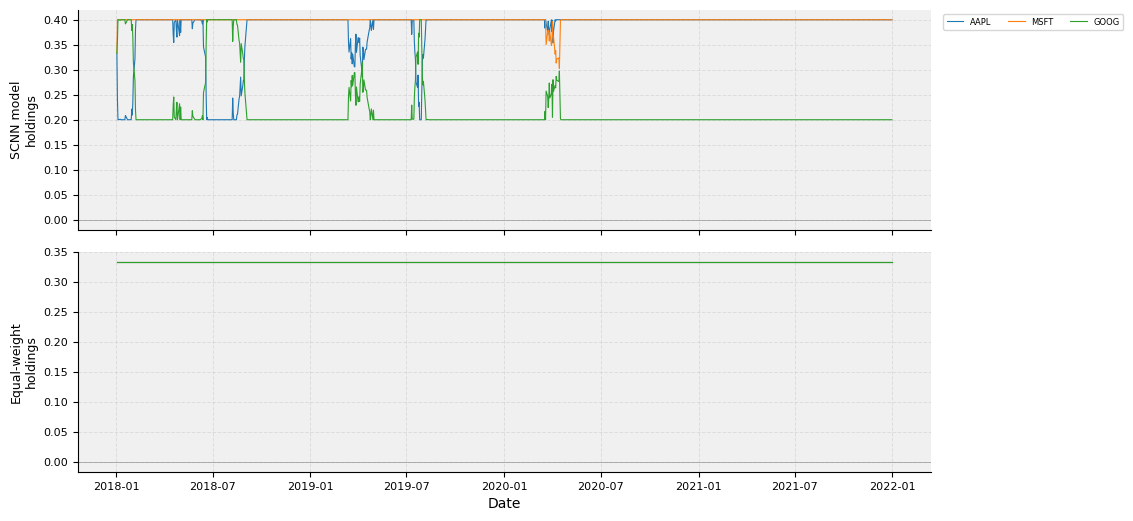

/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2982/2914626644.py:191: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  total = float(c.iloc[-1])
/var/folders/8k/svrsns315psc6cvlbw8nz54r0000gn/T/ipykernel_2982/2914626644.py:194: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  ann_v = float(daily.std(ddof=0)*np.sqrt(252))



Final cumulative return : 299.16%

Portfolio
Total :   3.99× (+299.2%)
AnnRet: 41.40%
AnnVol: 28.34%
Sharpe:   1.46

Benchmark
Total :   1.76× (+75.7%)
AnnRet: 15.14%
AnnVol: 21.24%
Sharpe:   0.71


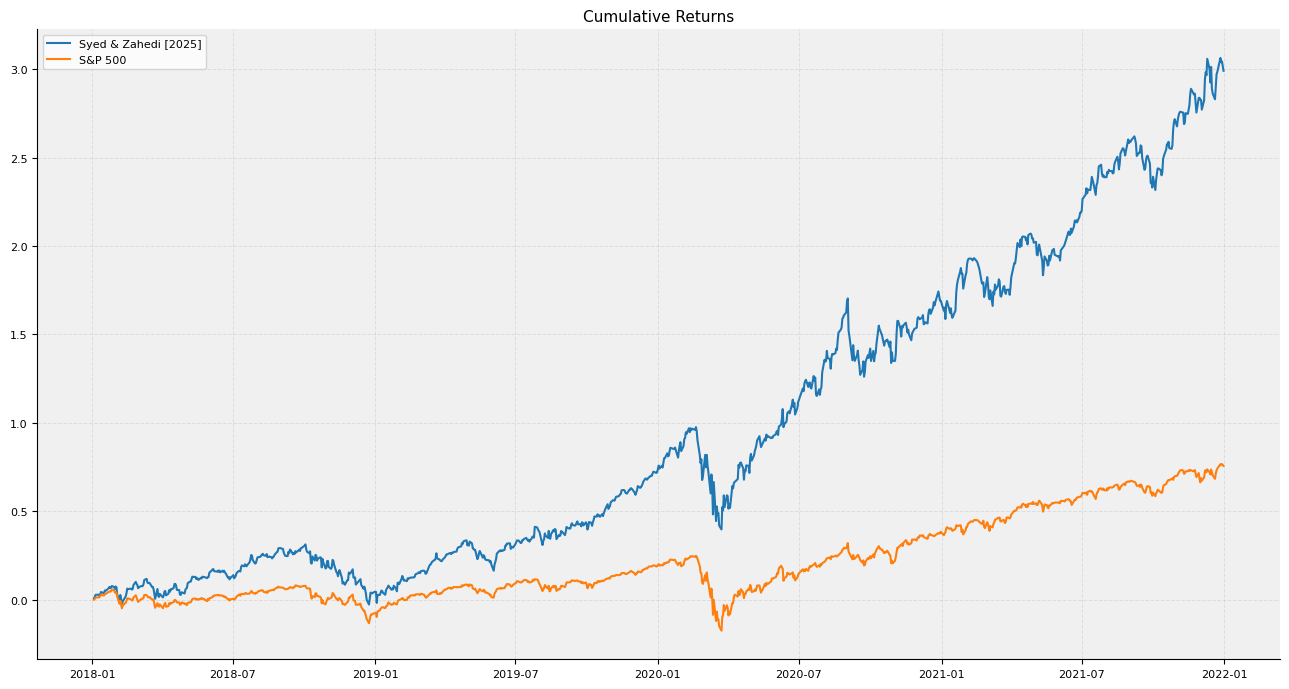

In [1]:
# -*- coding: utf-8 -*-
"""
SCNN-driven mean–variance portfolio demo
——————————————————————————————————————————
Features
• static one-shot optimiser (latest forecast)
• rolling back-test → cumulative P&L + weight matrix
• equal-weight baseline
• two-panel weight plot  (stratified vs. common)
• cumulative-return summary & benchmark plot
"""
from __future__ import annotations
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Tuple

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", message=r"This use of `\*`.*matrix")

# ───────────── user settings ─────────────
TICKERS   = ["AAPL", "MSFT", "GOOG"]
DATA_DIR  = Path(".")
FILE_TMPL = "{tkr}_2005_2021_clean.csv"
PRED_CSV  = Path("oos_predictions_2018on.csv")
SPX_CSV   = Path("sp500_2005_2021_clean.csv")

ROLL_WIN = 30
W_MAX    = 0.40

@dataclass
class Parameters:
    gamma_trade: float = 0.10
    gamma_risk : float = 0.50
    a_lin      : float = 1e-3
    b_nl       : float = 5e-4


# ═══ helper: axis styling ────────────────────────────────────────────
def style_axes(ax, *, is_bottom: bool = True) -> None:
    ax.set_facecolor("#f0f0f0")
    ax.grid(True, which="major", axis="both",
            linestyle="--", linewidth=0.7, alpha=0.3)
    ax.tick_params(labelsize=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if not is_bottom:
        ax.tick_params(labelbottom=False)


# ═══ realised-data helpers ───────────────────────────────────────────
def _clean_index(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.index = pd.to_datetime(df.index, errors="coerce")
    return df.loc[~df.index.isna()].sort_index()

def _split_num(df: pd.DataFrame, field: str) -> pd.Series:
    if field in df.columns:
        col = df[field]
    elif df.columns.nlevels == 2:
        col = df.xs(field, level=0, axis=1).squeeze()
    else:
        col = df.xs(("Price", field), axis=1).squeeze()
    return pd.to_numeric(col, errors="coerce")

def load_panels(tickers: List[str]) -> Tuple[pd.DataFrame, ...]:
    price, vol, hi, lo = {}, {}, {}, {}
    for t in tickers:
        raw = pd.read_csv(DATA_DIR / FILE_TMPL.format(tkr=t), index_col=0)\
                 .pipe(_clean_index)
        price[t] = _split_num(raw, "Adj Close")
        vol[t]   = _split_num(raw, "Volume")
        hi[t]    = _split_num(raw, "High")
        lo[t]    = _split_num(raw, "Low")
    return (pd.concat(d, axis=1).sort_index() for d in (price, vol, hi, lo))


# ═══ forecast helpers ────────────────────────────────────────────────
def load_predictions() -> pd.DataFrame:
    df = pd.read_csv(PRED_CSV, index_col=0, parse_dates=True)
    if df.columns.nlevels == 2 and df.columns.get_level_values(0)[0] == "Price":
        df.columns = df.columns.get_level_values(1)
    if "Price" in df.columns:
        df = df.drop(columns="Price")
    return df.sort_index()

def split_predictions(pred: pd.DataFrame) -> Tuple[pd.DataFrame, ...]:
    mu  = np.exp(pred[[f"{t}_log_ret"  for t in TICKERS]].apply(pd.to_numeric, errors="coerce")) - 1
    sig =        pred[[f"{t}_sigma20" for t in TICKERS]].apply(pd.to_numeric, errors="coerce")
    trn =        pred[[f"{t}_TurnUSD" for t in TICKERS]].apply(pd.to_numeric, errors="coerce")
    mu.columns = sig.columns = trn.columns = TICKERS
    return mu, sig, trn


# ═══ optimiser ────────────────────────────────────────────────────────
def optimise(mu, sig, trn, w_prev, aum, p):
    V_w = trn.values / aum
    z   = cp.Variable(len(mu))
    phi = cp.sum(p.a_lin*cp.abs(z) +
                 p.b_nl*sig.values*cp.power(cp.abs(z),1.5)/np.sqrt(V_w))
    risk= cp.quad_form(w_prev+z, np.diag(sig.values**2))
    cp.Problem(cp.Maximize(mu.values@z - p.gamma_trade*phi - p.gamma_risk*risk),
               [cp.sum(z)==0, w_prev+z>=0, w_prev+z<=W_MAX]).solve(solver="SCS")
    z_val = z.value
    return np.zeros(len(mu)) if z_val is None or np.isnan(z_val).any() else z_val


# ═══ one-shot static optimiser ───────────────────────────────────────
def static_opt_scnn(mu_hat: pd.Series,
                    sig_hat: pd.Series,
                    trn_hat: pd.Series,
                    *,
                    aum: float = 1e6,
                    w_prev: np.ndarray | None = None) -> None:
    n = len(mu_hat)
    if w_prev is None:
        w_prev = np.repeat(1/n, n)

    p   = Parameters()
    V_w = trn_hat.values / aum
    z   = cp.Variable(n)
    phi = cp.sum(p.a_lin*cp.abs(z) +
                 p.b_nl*sig_hat.values*cp.power(cp.abs(z),1.5)/np.sqrt(V_w))
    risk = cp.quad_form(w_prev+z, np.diag(sig_hat.values**2))

    cp.Problem(cp.Maximize(mu_hat.values@z - p.gamma_trade*phi - p.gamma_risk*risk),
               [cp.sum(z)==0, w_prev+z>=0, w_prev+z<=W_MAX]).solve(solver="SCS")

    z_val = z.value if z.value is not None else np.zeros(n)

    print("\nStatic optimisation (weight-space, SCNN)")
    print("μᵀz :", float(mu_hat.values @ z_val))
    print("φ_w :", float(phi.value))
    print("risk:", float(risk.value))
    print("Trades Δw :", np.round(z_val, 6))
    print("New weights:", np.round(w_prev + z_val, 6))


# ═══ rolling back-test ───────────────────────────────────────────────
def backtest(start: str, end: str, initial_capital=1e6):
    price, vol_s, hi, lo = load_panels(TICKERS)
    price, vol_s, hi, lo = (df.loc[start:end] for df in (price, vol_s, hi, lo))
    mu_hat, sig_hat, trn_hat = split_predictions(load_predictions().loc[start:end])

    good = ~(price.isna().any(axis=1) | mu_hat.isna().any(axis=1) |
             sig_hat.isna().any(axis=1) | trn_hat.isna().any(axis=1))
    price, mu_hat, sig_hat, trn_hat = (df[good] for df in (price, mu_hat, sig_hat, trn_hat))
    if price.empty: raise ValueError("No valid rows after NaN filtering.")

    dates = price.index
    turn_med = ((hi + lo)/2 * vol_s).rolling(ROLL_WIN).median().reindex(dates)\
                 .fillna(method="ffill").fillna(method="bfill")

    wealth   = np.full(len(dates), initial_capital, float)
    W        = np.zeros((len(dates), len(TICKERS))); W[0] = 1/len(TICKERS)
    W_hist   = W.copy()
    prm = Parameters()

    for t in range(len(dates)-1):
        z = optimise(mu_hat.iloc[t+1], sig_hat.iloc[t+1], trn_hat.iloc[t+1],
                     W[t], wealth[t], prm)
        W[t+1]      = W[t] + z
        W_hist[t+1] = W[t+1]

        gross = W[t+1] @ (price.iloc[t+1].values / price.iloc[t].values - 1)
        tm = np.maximum(turn_med.iloc[t+1].values, 1e-8)
        impact = np.sum(5e-4*sig_hat.iloc[t+1].values *
                        np.power(np.abs(z),1.5) / np.sqrt(tm/wealth[t]))
        wealth[t+1] = wealth[t] * (1 + gross - impact)

    cum = pd.Series(wealth[1:]/initial_capital - 1, index=dates[1:])
    return cum, pd.DataFrame(W_hist, index=dates, columns=TICKERS)


# ═══ equal-weight baseline ───────────────────────────────────────────
def equal_weight_backtest(start: str, end: str, tickers=TICKERS):
    dates = pd.date_range(start, end, freq="B")          # business-day index
    w = pd.DataFrame(1/len(tickers), index=dates, columns=tickers)  # constant
    cum = pd.Series(0.0, index=dates)                    # zero excess return
    return cum, w


# ═══ metrics / pretty print ──────────────────────────────────────────
def metrics(c: pd.Series) -> Dict[str, float]:
    if c.empty:
        return dict.fromkeys(["Total","AnnRet","AnnVol","Sharpe"], np.nan)
    total = float(c.iloc[-1])
    daily = c.diff().fillna(0) / (1 + c.shift())
    ann_r = float((1+total)**(252/len(c)) - 1)
    ann_v = float(daily.std(ddof=0)*np.sqrt(252))
    sharpe= ann_r/ann_v if ann_v>0 else np.nan
    return {"Total": total, "AnnRet": ann_r, "AnnVol": ann_v, "Sharpe": sharpe}

def pp(lbl, d):
    print(f"\n{lbl}")
    print(f"Total : {1+d['Total']:6.2f}× ({d['Total']:+6.1%})")
    print(f"AnnRet: {d['AnnRet']:6.2%}")
    print(f"AnnVol: {d['AnnVol']:6.2%}")
    print(f"Sharpe: {d['Sharpe']:6.2f}")


# ═══ benchmark loader ────────────────────────────────────────────────
def load_benchmark(start: str, end: str) -> pd.Series:
    df = pd.read_csv(SPX_CSV, index_col=0, parse_dates=True, header=[0,1])
    if df.columns.nlevels == 1:
        px = df["Adj Close"]
    elif df.columns.nlevels == 2:
        px = df.xs("Adj Close",
                   level=1 if df.columns.levels[0][0]=="Price" else 0, axis=1)
    else:
        px = df.xs(("Price","Adj Close"), axis=1).squeeze()
    px = px.sort_index().loc[start:end].ffill()
    return (1 + px.pct_change().fillna(0)).cumprod() - 1


# ═══ two-panel weight plot ───────────────────────────────────────────
def plot_two_weight_panels(w_strat, w_common,
                           *,
                           lab_strat="SCNN model\nholdings",
                           lab_common="Equal-weight\nholdings",
                           figsize=(11, 6)):

    fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True,
                                   figsize=figsize,
                                   gridspec_kw={"hspace": 0.10})

    # top panel: optimizer fed with ticker-specified SCNN
    ax1.axhline(0, color="grey", lw=0.4)      # zero-line
    for tkr in w_strat.columns:
        ax1.plot(w_strat.index, w_strat[tkr], lw=0.8, label=tkr)
    style_axes(ax1, is_bottom=False)
    ax1.set_ylabel(lab_strat, fontsize=9)
    ax1.legend(fontsize=6, ncol=len(w_strat.columns),
               loc="upper left", bbox_to_anchor=(1.01, 1.00))

    # --- bottom panel: equal holdings
    ax2.axhline(0, color="grey", lw=0.4)
    for tkr in w_common.columns:
        ax2.plot(w_common.index, w_common[tkr], lw=0.8, label=tkr)
    style_axes(ax2, is_bottom=True)
    ax2.set_ylabel(lab_common, fontsize=9)
    ax2.set_xlabel("Date")

    plt.tight_layout()
    plt.show()



# ═══ STATIC one-shot demo on latest SCNN forecast ────────────────────
pred_all = load_predictions()
mu_all, sig_all, trn_all = split_predictions(pred_all)
static_opt_scnn(mu_all.iloc[-1], sig_all.iloc[-1], trn_all.iloc[-1], aum=1e6)


# ═══ rolling back-tests & weight plot ────────────────────────────────
cum_strat,  weights_strat  = backtest("2018-01-02", "2021-12-31")
cum_common, weights_common = equal_weight_backtest("2018-01-02", "2021-12-31")

common_dates = weights_strat.index.intersection(weights_common.index)
plot_two_weight_panels(weights_strat.reindex(common_dates),
                       weights_common.reindex(common_dates))


# ═══ cumulative-return summary & benchmark figure ────────────────────
cum = cum_strat
print(f"\nFinal cumulative return : {cum.iloc[-1]:.2%}")
pp("Portfolio", metrics(cum))

bench = load_benchmark(cum.index[0].strftime("%Y-%m-%d"),
                       cum.index[-1].strftime("%Y-%m-%d"))
pp("Benchmark", metrics(bench.reindex(cum.index)))

fig, ax = plt.subplots(figsize=(13,7))
ax.plot(cum,   label="Syed & Zahedi [2025]")
ax.plot(bench, label="S&P 500")
style_axes(ax, is_bottom=True)
ax.set_title("Cumulative Returns", fontsize=11)
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()